# 📦 Etapa 1 - Configuração:

Importando Bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

Configurações Visuais

In [ ]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12

Carregamento dos Dados

In [ ]:
df_poupanca = pd.read_excel ('/content/drive/MyDrive/DataSet/ipeadata[14-04-2026-05-47].xls', engine='xlrd')

In [ ]:
df_poupanca.head()

,Sigla,Codigo,Meso-região,2017,2018,2019,2020,2021,2022
0,AC,1201,Vale do Juruá,1.068092e+05,1.190721e+05,1.265133e+05,1.655292e+05,1.518060e+05,1.516899e+05
1,AC,1202,Vale do Acre,5.291872e+05,5.738404e+05,5.945268e+05,7.574949e+05,6.471738e+05,6.009223e+05
2,AL,2701,Sertão Alagoano,2.481335e+05,2.676963e+05,2.847237e+05,3.616679e+05,2.989937e+05,3.130860e+05
3,AL,2702,Agreste Alagoano,4.596145e+05,4.895653e+05,5.178858e+05,6.429205e+05,5.331555e+05,5.669906e+05
4,AL,2703,Leste Alagoano,2.686841e+06,2.801348e+06,2.825358e+06,3.361072e+06,3.054137e+06,2.890192e+06


# 🔍 Etapa 2 - Exploração Inicial:

Dimensões e Estrutura

In [ ]:
# Revela o tamanho do dataset.
dimensoes_dataset = f" {df_poupanca.shape[0]} meso-regiões / {df_poupanca.shape[1]} Colunas"
print('Dimensões do Dataset:', dimensoes_dataset)

Dimensões do Dataset:  137 meso-regiões / 9 Colunas


In [ ]:
# Revela o tipo de dado em cada coluna.
tipos_dados_coluna = df_poupanca.dtypes
print('Tipos de Dados por Coluna:', tipos_dados_coluna)

Tipos de Dados por Coluna: Sigla           object
Codigo           int64
Meso-região     object
2017           float64
2018           float64
2019           float64
2020           float64
2021           float64
2022           float64
dtype: object


In [ ]:
# Verificação de Valores Nulos - Se existe alguma célular vazia no dataset.
valoresnulos_coluna = df_poupanca.isnull().sum()
print('Valores Nulos por Coluna:', valoresnulos_coluna)

Valores Nulos por Coluna: Sigla          0
Codigo         0
Meso-região    0
2017           0
2018           0
2019           0
2020           0
2021           0
2022           0
dtype: int64


In [ ]:
# Resumo estatístico de todas as colunas numéricas do dataset.
estatisticas_descritivas = df_poupanca.describe()
print('Estatísticas Descritivas:', estatisticas_descritivas)

Estatísticas Descritivas:             Codigo          2017          2018          2019          2020  \
count   137.000000  1.370000e+02  1.370000e+02  1.370000e+02  1.370000e+02   
mean   3131.007299  3.229373e+06  3.399211e+06  3.459077e+06  3.977637e+06   
std    1109.946021  8.576090e+06  8.962505e+06  9.051011e+06  1.062212e+07   
min    1101.000000  1.316936e+04  1.589548e+04  1.650416e+04  2.501253e+04   
25%    2306.000000  5.435268e+05  5.985728e+05  6.104559e+05  7.574949e+05   
50%    3107.000000  1.107065e+06  1.163525e+06  1.175445e+06  1.411813e+06   
75%    4104.000000  2.721083e+06  2.842128e+06  2.867920e+06  3.313108e+06   
max    5301.000000  8.403151e+07  8.774407e+07  8.848567e+07  1.070794e+08   

               2021          2022  
count  1.370000e+02  1.370000e+02  
mean   3.561124e+06  3.174255e+06  
std    9.254042e+06  8.224553e+06  
min    2.031570e+04  1.798012e+04  
25%    6.526320e+05  6.326421e+05  
50%    1.260247e+06  1.137882e+06  
75%    2.943266e+06

### 💡 Insight — Concentração Regional da Poupança
---
Em todos os anos analisados, a média dos depósitos foi aproximadamente **3
vezes superior** à mediana, evidenciando uma concentração persistente e estrutural da poupança em poucas meso-regiões brasileiras.

# 🔧 Etapa 3 - Transformação dos Dados:

🔧 O dataset se encontra no formato **Wide (largo)**, cada ano é uma coluna separada. Este formato é bom para visualizar, mas dificulta análises, como comparar anos, calcular variações e criar gráficos temporais. Será necessário tranformá-lo para o formato **Long (longo)**, onde cada linha será uma combinação de região + ano.

In [ ]:
df_long = df_poupanca.melt (
    id_vars= ['Sigla','Codigo','Meso-região'], # Colunas que ficam fixas na tranformação.
    value_vars= ['2017','2018','2019','2020','2021','2022'], # Colunas que irão virar linhas.
    var_name = 'Ano', # Nome da nova coluna de anos
    value_name = 'Depositos' # Nome da nova coluna de depósitos
)

In [ ]:
# Tabela em formato original: **Wide**
df_poupanca.head(5)

,Sigla,Codigo,Meso-região,2017,2018,2019,2020,2021,2022
0,AC,1201,Vale do Juruá,1.068092e+05,1.190721e+05,1.265133e+05,1.655292e+05,1.518060e+05,1.516899e+05
1,AC,1202,Vale do Acre,5.291872e+05,5.738404e+05,5.945268e+05,7.574949e+05,6.471738e+05,6.009223e+05
2,AL,2701,Sertão Alagoano,2.481335e+05,2.676963e+05,2.847237e+05,3.616679e+05,2.989937e+05,3.130860e+05
3,AL,2702,Agreste Alagoano,4.596145e+05,4.895653e+05,5.178858e+05,6.429205e+05,5.331555e+05,5.669906e+05
4,AL,2703,Leste Alagoano,2.686841e+06,2.801348e+06,2.825358e+06,3.361072e+06,3.054137e+06,2.890192e+06


In [ ]:
# Tabela em novo formato: **Long**
df_long.head(5)

,Sigla,Codigo,Meso-região,Ano,Depositos
0,AC,1201,Vale do Juruá,2017,1.068092e+05
1,AC,1202,Vale do Acre,2017,5.291872e+05
2,AL,2701,Sertão Alagoano,2017,2.481335e+05
3,AL,2702,Agreste Alagoano,2017,4.596145e+05
4,AL,2703,Leste Alagoano,2017,2.686841e+06


🔧 A coluna **Ano** esta guardando os valores dos anos como texto, porque eram nomes de colunas originalmente. Será necessária um ajuste para converter **Ano** para número inteiro, para que assim possamos ordernar corretamente as
informações dessa nova coluna e poder criar gráficos temporais.



In [ ]:
df_long['Ano'] = df_long['Ano'].astype(int) # Conversão de texto para número inteiro.

In [ ]:
df_poupanca.dtypes # Antes os anos eram float64 - texto.

,0
Sigla,object
Codigo,int64
Meso-região,object
2017,float64
2018,float64
2019,float64
2020,float64
2021,float64
2022,float64


In [ ]:
df_long.dtypes # Após a conversão, ano se tornou int64 - número inteiro.

,0
Sigla,object
Codigo,int64
Meso-região,object
Ano,int64
Depositos,float64


# 📊 Etapa 4 - Estatística Descritiva:

## 1. Análise - Concentração por UF

---

Permite a identificação de quais regiões do Brasil há maior concentração de poupança, sendo agrupado os dados das meso-regiões pelos seus respectivos estados (UF). Essa abordagem permite uma visão comparativa entre as unidades federativas, evidenciando onde se concentram os maiores volumes de poupança no país entre 2017 a 2022.

In [ ]:
# Agrupando por estados e somando os depósitos de todos os anos.
por_uf = df_long.groupby('Sigla')['Depositos'].sum().reset_index()
print('Agrupando por estados:', por_uf)

Agrupando por estados:    Sigla     Depositos
0     AC  4.524565e+06
1     AL  2.260338e+07
2     AM  1.885359e+07
3     AP  3.457351e+06
4     BA  1.275014e+08
5     CE  6.462303e+07
6     DF  7.844098e+07
7     ES  5.187738e+07
8     GO  7.302399e+07
9     MA  3.400171e+07
10    MG  2.994796e+08
11    MS  2.199502e+07
12    MT  2.538313e+07
13    PA  3.819845e+07
14    PB  3.113476e+07
15    PE  7.799668e+07
16    PI  2.507169e+07
17    PR  1.641557e+08
18    RJ  3.433837e+08
19    RN  2.487150e+07
20    RO  1.216075e+07
21    RR  3.062112e+06
22    RS  2.484816e+08
23    SC  1.142263e+08
24    SE  2.308433e+07
25    SP  9.079582e+08
26    TO  1.014168e+07


##### ⚠️ Observação: Os valores numéricos estão exibidos em **notação científica** pelo Pandas. Isso ocorre porque os depósitos de poupança são valores monetários de grande magnitude. Para interpretar corretamente, observe o expoente: e+06 = milhões, e+07 = dezenas de milhões, e+08 = centenas de milhões.

In [ ]:
# Ordenando do MAIOR para o MENOR.
por_uf = por_uf.sort_values('Depositos', ascending=False).reset_index(drop=True)
print('Ordenando do MAIOR para o MENOR:', por_uf)

Ordenando do MAIOR para o MENOR:    Sigla     Depositos
0     SP  9.079582e+08
1     RJ  3.433837e+08
2     MG  2.994796e+08
3     RS  2.484816e+08
4     PR  1.641557e+08
5     BA  1.275014e+08
6     SC  1.142263e+08
7     DF  7.844098e+07
8     PE  7.799668e+07
9     GO  7.302399e+07
10    CE  6.462303e+07
11    ES  5.187738e+07
12    PA  3.819845e+07
13    MA  3.400171e+07
14    PB  3.113476e+07
15    MT  2.538313e+07
16    PI  2.507169e+07
17    RN  2.487150e+07
18    SE  2.308433e+07
19    AL  2.260338e+07
20    MS  2.199502e+07
21    AM  1.885359e+07
22    RO  1.216075e+07
23    TO  1.014168e+07
24    AC  4.524565e+06
25    AP  3.457351e+06
26    RR  3.062112e+06


In [ ]:
# Formatando valores em MILHÕES para facilitar leitura.
por_uf['Depositos_MM'] = (por_uf['Depositos']/1_000_000).round(1)
print('Depositos em MILHÕES:', por_uf)

Depositos em MILHÕES:    Sigla     Depositos  Depositos_MM
0     SP  9.079582e+08         908.0
1     RJ  3.433837e+08         343.4
2     MG  2.994796e+08         299.5
3     RS  2.484816e+08         248.5
4     PR  1.641557e+08         164.2
5     BA  1.275014e+08         127.5
6     SC  1.142263e+08         114.2
7     DF  7.844098e+07          78.4
8     PE  7.799668e+07          78.0
9     GO  7.302399e+07          73.0
10    CE  6.462303e+07          64.6
11    ES  5.187738e+07          51.9
12    PA  3.819845e+07          38.2
13    MA  3.400171e+07          34.0
14    PB  3.113476e+07          31.1
15    MT  2.538313e+07          25.4
16    PI  2.507169e+07          25.1
17    RN  2.487150e+07          24.9
18    SE  2.308433e+07          23.1
19    AL  2.260338e+07          22.6
20    MS  2.199502e+07          22.0
21    AM  1.885359e+07          18.9
22    RO  1.216075e+07          12.2
23    TO  1.014168e+07          10.1
24    AC  4.524565e+06           4.5
25    AP  3.4573

In [ ]:
# Tabela do Ranking de Depósitos
Ranking_depositos_uf = por_uf[['Sigla', 'Depositos_MM']]
print('Ranking de Depósitos por UF 2017-2022, em milhões R$:', Ranking_depositos_uf)

Ranking de Depósitos por UF 2017-2022, em milhões R$:    Sigla  Depositos_MM
0     SP         908.0
1     RJ         343.4
2     MG         299.5
3     RS         248.5
4     PR         164.2
5     BA         127.5
6     SC         114.2
7     DF          78.4
8     PE          78.0
9     GO          73.0
10    CE          64.6
11    ES          51.9
12    PA          38.2
13    MA          34.0
14    PB          31.1
15    MT          25.4
16    PI          25.1
17    RN          24.9
18    SE          23.1
19    AL          22.6
20    MS          22.0
21    AM          18.9
22    RO          12.2
23    TO          10.1
24    AC           4.5
25    AP           3.5
26    RR           3.1


##### 📉​ Gráfico - Ranking de Depósitos por UF
---
Gráfico de barras horizontais com os 27 estados ordenados do maior para o melhor volume de depósitos.


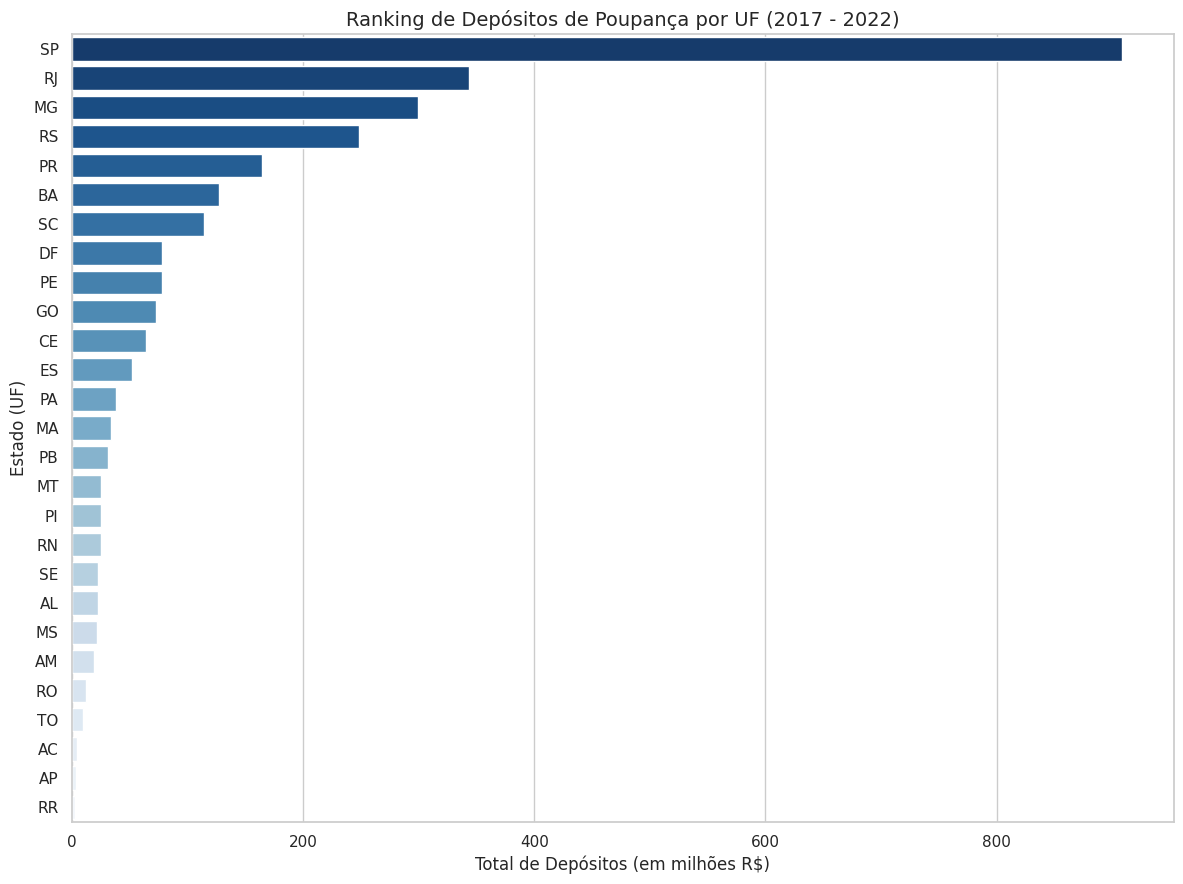

In [ ]:
plt.figure(figsize=(12,9))

sns.barplot(
    data= por_uf,
    x = 'Depositos_MM',
    y = 'Sigla',
    hue = 'Sigla',
    palette = 'Blues_r',
    legend = False
)

plt.title('Ranking de Depósitos de Poupança por UF (2017 - 2022)', fontsize =14)
plt.xlabel('Total de Depósitos (em milhões R$)')
plt.ylabel('Estado (UF)')
plt.tight_layout()
plt.show()

###💡 Insights — Concentração por UF

---

São Paulo concentra sozinho aproximadamente 908 milhões em depósitos
de poupança no período 2017-2022 — mais do que o dobro do segundo
colocado (RJ). Os três menores estados são todos da região Norte
(AC, AP, RR), revelando uma desigualdade regional estrutural
de até 293 vezes entre o maior e o menor.

---
São Paulo sozinho acumula quase o mesmo volume de depósitos que Rio de Janeiro, Minas Gerais e Rio Grande do Sul juntos — os três estados que ocupam as posições seguintes no ranking


## 2. Análise - Variação Percentual por Meso-Região

---
Permite identificar quais meso-regiões registraram crescimento ou retração nos depósitos de poupança entre 2017 a 2022.


In [ ]:
# Calculando variação percentual 2017 a 2022.
df_poupanca['Variacao_%'] = (
    (df_poupanca['2022'] - df_poupanca['2017']) / df_poupanca['2017'] * 100
).round(1)
print('Variação Percentual:', df_poupanca)

Variação Percentual:     Sigla  Codigo                 Meso-região          2017          2018  \
0      AC    1201               Vale do Juruá  1.068092e+05  1.190721e+05   
1      AC    1202                Vale do Acre  5.291872e+05  5.738404e+05   
2      AL    2701             Sertão Alagoano  2.481335e+05  2.676963e+05   
3      AL    2702            Agreste Alagoano  4.596145e+05  4.895653e+05   
4      AL    2703              Leste Alagoano  2.686841e+06  2.801348e+06   
..    ...     ...                         ...           ...           ...   
132    SP    3513    Vale do Paraíba Paulista  5.973068e+06  6.373497e+06   
133    SP    3514        Litoral Sul Paulista  8.070521e+05  8.581621e+05   
134    SP    3515  Metropolitana de São Paulo  8.403151e+07  8.774407e+07   
135    TO    1701      Ocidental do Tocantins  7.763200e+05  8.669041e+05   
136    TO    1702       Oriental do Tocantins  6.124631e+05  6.773815e+05   

             2019          2020          2021         

###### Variação Percentual  

---

É uma medida que indica o quanto um valor cresceu ou diminuiu em relação ao seu ponto de partida, expressando essa mudança em %.
Sua fórmula é: **Variação % = ((Valor Final - Valor Inicial) / Valor Inicial) × 100**. Um resultado positivo indica crescimento; Um valor negativo indica queda.

---
Comparar os valores absolutos de depósitos entre meso-regiões seria injusto, uma região grande naturalmente tem mais depósitos que uma pequena, independente do seu desempenho. A variação percentual nivel esse campo: Ela mostra o RITMO de crescimento ou queda de cada região, independente do seu tamanho ou volume inicial.


In [ ]:
# Top 10 meso-regiões que mais CRESCERAM.
top_crescimento = df_poupanca.nlargest(10, 'Variacao_%')[['Meso-região', 'Sigla', 'Variacao_%']].reset_index(drop=True)
print('Top 10 meso-regiões que mais CRESCERAM:', top_crescimento.to_string(index=False))

Top 10 meso-regiões que mais CRESCERAM:                     Meso-região Sigla  Variacao_%
                 Sul de Roraima    RR        82.7
                  Vale do Juruá    AC        42.0
                         Marajó    PA        37.9
                 Norte do Amapá    AP        36.5
         Ocidental do Tocantins    TO        35.5
                 Sul Amazonense    AM        34.1
               Sudeste Paraense    PA        34.1
                 Sul Maranhense    MA        31.5
Litoral Norte Espírito-santense    ES        29.0
              Nordeste Paraense    PA        28.3


In [ ]:
# Top 10 meso-regiões que mais tiveram QUEDA.
top_queda = df_poupanca.nsmallest(10, 'Variacao_%')[['Meso-região', 'Sigla', 'Variacao_%']].reset_index(drop=True)
print('Top 10 meso-regiões que mais tiveram QUEDA:', top_queda.to_string(index=False))

Top 10 meso-regiões que mais tiveram QUEDA:                     Meso-região Sigla  Variacao_%
                      Borborema    PB       -21.2
 Centro Ocidental Rio-grandense    RS       -15.2
  Centro Oriental Rio-grandense    RS       -14.3
         Noroeste Rio-grandense    RS       -14.0
              Oeste Catarinense    SC       -14.0
               Oeste Paranaense    PR       -13.3
Metropolitana do Rio de Janeiro    RJ       -13.3
     Metropolitana de Fortaleza    CE       -12.9
         Nordeste Rio-grandense    RS       -12.5
                Madeira-Guaporé    RO       -12.2


##### 📉​ Gráfico - Top 10 Crescimento e Queda

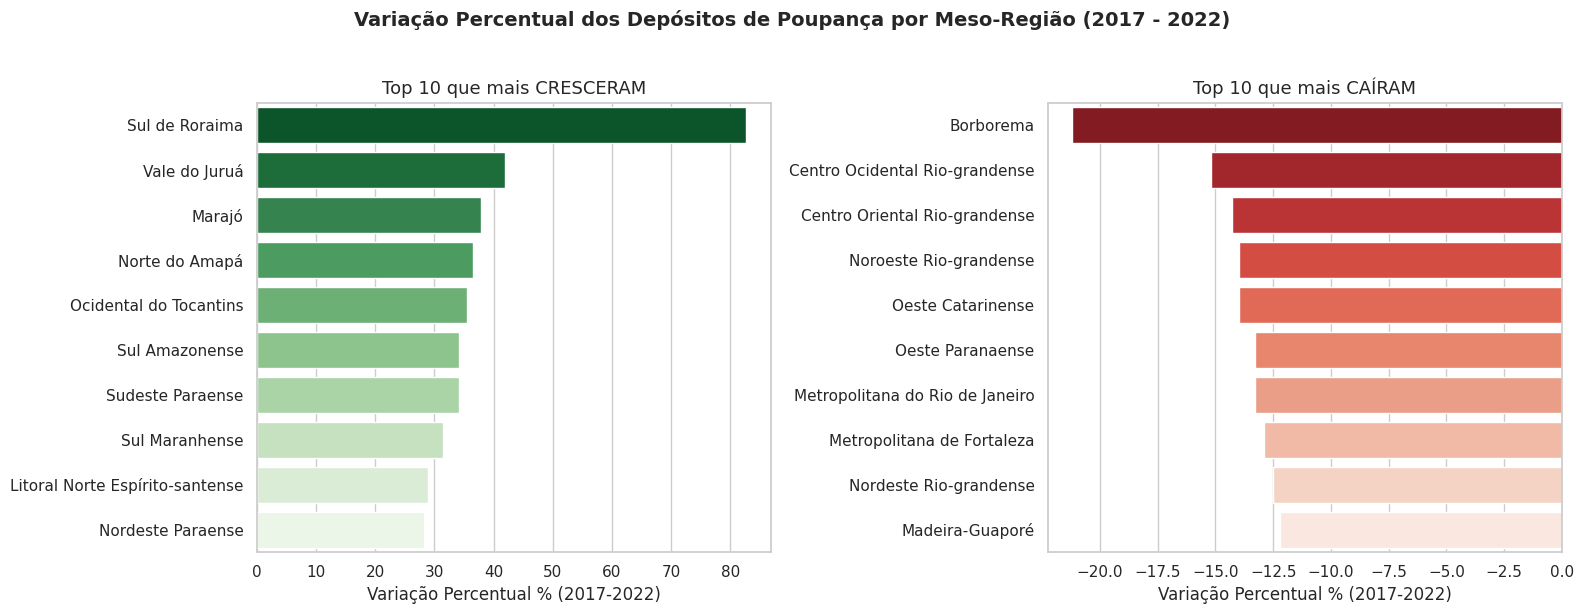

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Top 10 Crescimento
sns.barplot(
    data = top_crescimento,
    x = 'Variacao_%',
    y = 'Meso-região',
    hue = 'Meso-região',
    palette = 'Greens_r',
    legend = False,
    ax = ax1
)

ax1.set_title('Top 10 que mais CRESCERAM', fontsize=13)
ax1.set_xlabel('Variação Percentual % (2017-2022)')
ax1.set_ylabel('')


# Gráfico 2: Top 10 Queda
sns.barplot(
    data = top_queda,
    x = 'Variacao_%',
    y = 'Meso-região',
    hue = 'Meso-região',
    palette = 'Reds_r',
    legend = False,
    ax = ax2
)

ax2.set_title('Top 10 que mais CAÍRAM', fontsize=13)
ax2.set_xlabel('Variação Percentual % (2017-2022)')
ax2.set_ylabel('')

# Título Geral dos Gráficos
plt.suptitle('Variação Percentual dos Depósitos de Poupança por Meso-Região (2017 - 2022)', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

### 💡 Insight — Variação Percentual por Meso-região

As regiões que mais cresceram percentualmente no período
2017-2022 pertencem quase que inteiramente ao Norte e Nordeste,
com destaque para Sul de Roraima (82,7%). Em contrapartida,
as maiores quedas se concentram no Sul do país e nas grandes
metrópoles, como Metropolitana do RJ (-13,3%) e múltiplas
meso-regiões do RS.

---

No entanto, há um paradoxo importante: as regiões que mais
cresceram percentualmente são quase as mesmas que ocupam os
últimos lugares na concentração absoluta de depósitos.
Isso revela que crescimento relativo e volume absoluto são
dimensões complementares — analisar apenas uma delas levaria
a conclusões incompletas sobre a realidade financeira
regional do Brasil.

## Análise 3 - Norte vs Sul

---

Permite comparar a evolução dos depósitos de poupança entre as regiões ***Norte e Sul***, duas regiões historicamente opostas em desenvolvimento econômico.

In [ ]:
# Definindo os Estados de cada Região
norte = ['AC', 'AM','AP','PA', 'RR', 'RO', 'TO']
sul = ['PR', 'SC', 'RS']

In [ ]:
# Filtrar o df_long para cada região
df_norte = df_long[df_long['Sigla'].isin(norte)].copy()
df_sul = df_long[df_long['Sigla'].isin(sul)].copy()

In [ ]:
# Somando os depósitos por ano em cada região.
evolucao_norte = df_norte.groupby('Ano')['Depositos'].sum().reset_index()
evolucao_sul = df_sul.groupby('Ano')['Depositos'].sum().reset_index()

In [ ]:
# Adicionando Coluna Identificadora
evolucao_norte ['Regiao'] = 'Norte'
evolucao_sul['Regiao'] = 'Sul'

evolucao = pd.concat([evolucao_norte, evolucao_sul])
print('Evolução por Região:', evolucao)

Evolução por Região:     Ano     Depositos Regiao
0  2017  1.324917e+07  Norte
1  2018  1.412359e+07  Norte
2  2019  1.446472e+07  Norte
3  2020  1.781030e+07  Norte
4  2021  1.605616e+07  Norte
5  2022  1.469456e+07  Norte
0  2017  8.151819e+07    Sul
1  2018  8.713771e+07    Sul
2  2019  8.860596e+07    Sul
3  2020  9.916220e+07    Sul
4  2021  9.134784e+07    Sul
5  2022  7.909176e+07    Sul


In [ ]:
# Convertendo Depósitos para MILHÕES.
evolucao['Depositos_MM'] = (evolucao['Depositos']/1_000_000).round(1)
print('Evolução por Região em MILHÕES:', evolucao)

Evolução por Região em MILHÕES:     Ano     Depositos Regiao  Depositos_MM
0  2017  1.324917e+07  Norte          13.2
1  2018  1.412359e+07  Norte          14.1
2  2019  1.446472e+07  Norte          14.5
3  2020  1.781030e+07  Norte          17.8
4  2021  1.605616e+07  Norte          16.1
5  2022  1.469456e+07  Norte          14.7
0  2017  8.151819e+07    Sul          81.5
1  2018  8.713771e+07    Sul          87.1
2  2019  8.860596e+07    Sul          88.6
3  2020  9.916220e+07    Sul          99.2
4  2021  9.134784e+07    Sul          91.3
5  2022  7.909176e+07    Sul          79.1


##### 📉​ Gráfico - Evolução dos Depósitos de Poupança - NORTE vs SUL

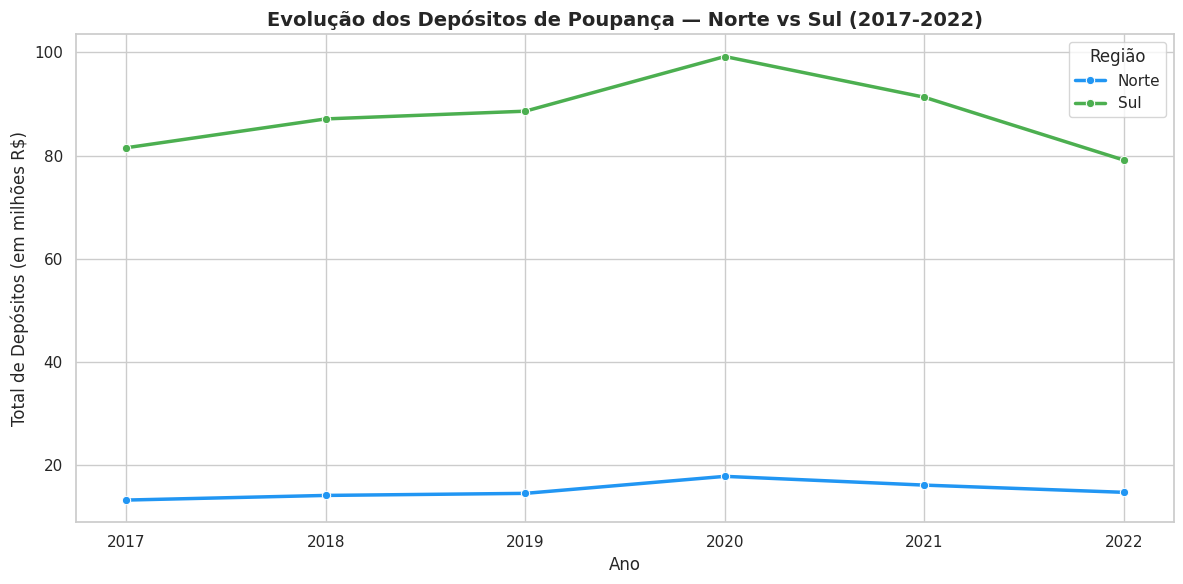

In [ ]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=evolucao,
    x='Ano',
    y='Depositos_MM',
    hue='Regiao',
    palette={'Norte': '#2196F3', 'Sul': '#4CAF50'},
    marker='o',
    linewidth=2.5
)

plt.title('Evolução dos Depósitos de Poupança — Norte vs Sul (2017-2022)',
          fontsize=14, fontweight='bold')
plt.xlabel('Ano')
plt.ylabel('Total de Depósitos (em milhões R$)')
plt.xticks([2017, 2018, 2019, 2020, 2021, 2022])
plt.legend(title='Região')
plt.tight_layout()
plt.show()

###💡 Insights — Norte vs Sul

---

O Sul apresentou consistentemente entre 5 e 6 vezes mais depósitos de poupança que o Norte durante todo o período analisado — mesmo sendo composto por apenas 3 estados contra 7 do Norte. Isso evidencia uma desigualdade regional profunda e estrutural no sistema financeiro brasileiro.

---
A região Norte apresentou crescimento consistente de 2017 a 2020, atingindo seu pico em R$ 17,8 milhões. A partir de 2021 iniciou uma queda progressiva retornando em 2022 a patamares próximos ao início do período analisado. O crescimento até 2020 pode estar associado ao impacto do auxílio emergencial
nas regiões mais vulneráveis do país.

---
A região Sul demonstrou comportamento volátil ao longo do período — subindo de 81,5 milhões em 2017 para um pico de 99,2 milhões em 2020, recuando para
91,3 milhões em 2021 e caindo para 79,1 milhões em 2022. Apesar da volatilidade, o Sul manteve seu patamar absoluto muito superior ao Norte em todos os anos.

---
As duas regiões atingiram seu pico máximo de depósitos exatamente em 2020 — o ano da pandemia de COVID-19. Isso sugere que o comportamento de acúmulo de poupança naquele ano foi um fenômeno nacional, independente do nível de desenvolvimento regional, possivelmente impulsionado pela retração do consumo e pelo auxílio emergencial.


## Análise 4 - Impacto da Pandemia

---
Nesta análise, avaliaremos quais regiões sentiram mais o efeito da COVID-19 nos depósitos de poupança.


Nas análises anteriores já foi observado que 2020 foi o ano pico em duas regiões: Norte e Sul. Mas agora analisaremos mais profundamente os resultados da pandemia.

---

A pandemia afetou a poupança em duas fase:


*   **Choque**: Que foi do período de 2019 a 2020, no qual houve *retratação* do consumo + auxílio emergencial, resultando no pico de depósitos de poupança.
*   **Recuperação**: Do período de 2020 a 2021, onde houve a *retomada* do consumo + inflação, resultando na forte queda de depósitos de poupança.



In [ ]:
# Calculando Variação da Fase 1 - Choque (2019 a 2020)
df_poupanca['Impacto_2020_%'] = ((df_poupanca['2020']- df_poupanca['2019'])/df_poupanca['2019']*100).round(1)
print('Variação da Fase 1 - Choque (2019 a 2020):', df_poupanca)

Variação da Fase 1 - Choque (2019 a 2020):     Sigla  Codigo                 Meso-região          2017          2018  \
0      AC    1201               Vale do Juruá  1.068092e+05  1.190721e+05   
1      AC    1202                Vale do Acre  5.291872e+05  5.738404e+05   
2      AL    2701             Sertão Alagoano  2.481335e+05  2.676963e+05   
3      AL    2702            Agreste Alagoano  4.596145e+05  4.895653e+05   
4      AL    2703              Leste Alagoano  2.686841e+06  2.801348e+06   
..    ...     ...                         ...           ...           ...   
132    SP    3513    Vale do Paraíba Paulista  5.973068e+06  6.373497e+06   
133    SP    3514        Litoral Sul Paulista  8.070521e+05  8.581621e+05   
134    SP    3515  Metropolitana de São Paulo  8.403151e+07  8.774407e+07   
135    TO    1701      Ocidental do Tocantins  7.763200e+05  8.669041e+05   
136    TO    1702       Oriental do Tocantins  6.124631e+05  6.773815e+05   

             2019          2020 

In [ ]:
# Calculando Variação da Fase 2 - Recuperação (2020 a 2021)
df_poupanca['Impacto_2021_%'] = ((df_poupanca['2021']- df_poupanca['2020'])/df_poupanca['2020']*100).round(1)
print('Variação da Fase 2 - Recuperação (2020 a 2021):', df_poupanca)

Variação da Fase 2 - Recuperação (2020 a 2021):     Sigla  Codigo                 Meso-região          2017          2018  \
0      AC    1201               Vale do Juruá  1.068092e+05  1.190721e+05   
1      AC    1202                Vale do Acre  5.291872e+05  5.738404e+05   
2      AL    2701             Sertão Alagoano  2.481335e+05  2.676963e+05   
3      AL    2702            Agreste Alagoano  4.596145e+05  4.895653e+05   
4      AL    2703              Leste Alagoano  2.686841e+06  2.801348e+06   
..    ...     ...                         ...           ...           ...   
132    SP    3513    Vale do Paraíba Paulista  5.973068e+06  6.373497e+06   
133    SP    3514        Litoral Sul Paulista  8.070521e+05  8.581621e+05   
134    SP    3515  Metropolitana de São Paulo  8.403151e+07  8.774407e+07   
135    TO    1701      Ocidental do Tocantins  7.763200e+05  8.669041e+05   
136    TO    1702       Oriental do Tocantins  6.124631e+05  6.773815e+05   

             2019          

In [ ]:
# Ranking 10 que mais CRESCERAM na fase 1
top_choque = df_poupanca.nlargest(10, 'Impacto_2020_%')[['Meso-região', 'Sigla', 'Impacto_2020_%']].reset_index(drop=True)
print(top_choque)

         Meso-região Sigla  Impacto_2020_%
0     Norte do Amapá    AP            59.2
1             Marajó    PA            46.8
2     Sul Amazonense    AM            43.0
3   Sudeste Paraense    PA            40.6
4     Sul de Roraima    RR            38.3
5  Sudoeste Paraense    PA            36.8
6       Sul do Amapá    AP            36.1
7  Centro Maranhense    MA            34.6
8   Oeste Maranhense    MA            34.3
9   Leste Maranhense    MA            34.0


In [ ]:
# Ranking 10 que mais CAÍRAM na fase 2
top_queda = df_poupanca.nsmallest(10, 'Impacto_2021_%')[['Meso-região', 'Sigla', 'Impacto_2021_%']].reset_index(drop=True)
print(top_queda)

           Meso-região Sigla  Impacto_2021_%
0     Sertão Sergipano    SE           -25.2
1       Norte do Amapá    AP           -22.7
2            Borborema    PB           -21.1
3    Sertões Cearenses    CE           -20.0
4               Marajó    PA           -19.8
5       Norte Cearense    CE           -19.3
6  Centro-Sul Cearense    CE           -18.6
7         Sul Cearense    CE           -18.2
8      Sertão Alagoano    AL           -17.3
9            Jaguaribe    CE           -17.3


##### 📉​ Gráfico - Impacto da Pandemia

### 💡 Insight — Impacto da Pandemia nos Depósitos de Poupança

A pandemia de COVID-19 revelou comportamentos financeiros regionais distintos em duas fases bem definidas.

---
Na **Fase 1 (2019→2020)**, as regiões *Norte e Nordeste* lideraram o crescimento dos depósitos, com destaque para Norte do Amapá (+59,2%) e Marajó (+46,8%). Regiões historicamente mais vulneráveis acumularam poupança de forma expressiva, impulsionadas principalmente pelo auxílio emergencial.

---
Na **Fase 2 (2020→2021)**, o movimento se inverteu. **Grandes metrópoles do Sul e Sudeste** lideraram os resgates, com quedas de até -10,6% na Metropolitana do Rio de Janeiro e -10,5% no Noroeste Paranaense. Regiões com maior densidade
populacional e economia mais ativa tenderam a resgatar os recursos mais rapidamente, pressionadas pela retomada do consumo e do custo de vida elevado.

---
Esse movimento revela que a pandemia não impactou o Brasil de forma uniforme, ela amplificou comportamentos financeiros já existentes entre regiões desenvolvidas e vulneráveis, tornando visível nos dados uma desigualdade que vai além dos números: é uma desigualdade de ritmo, de acesso e de oportunidade.



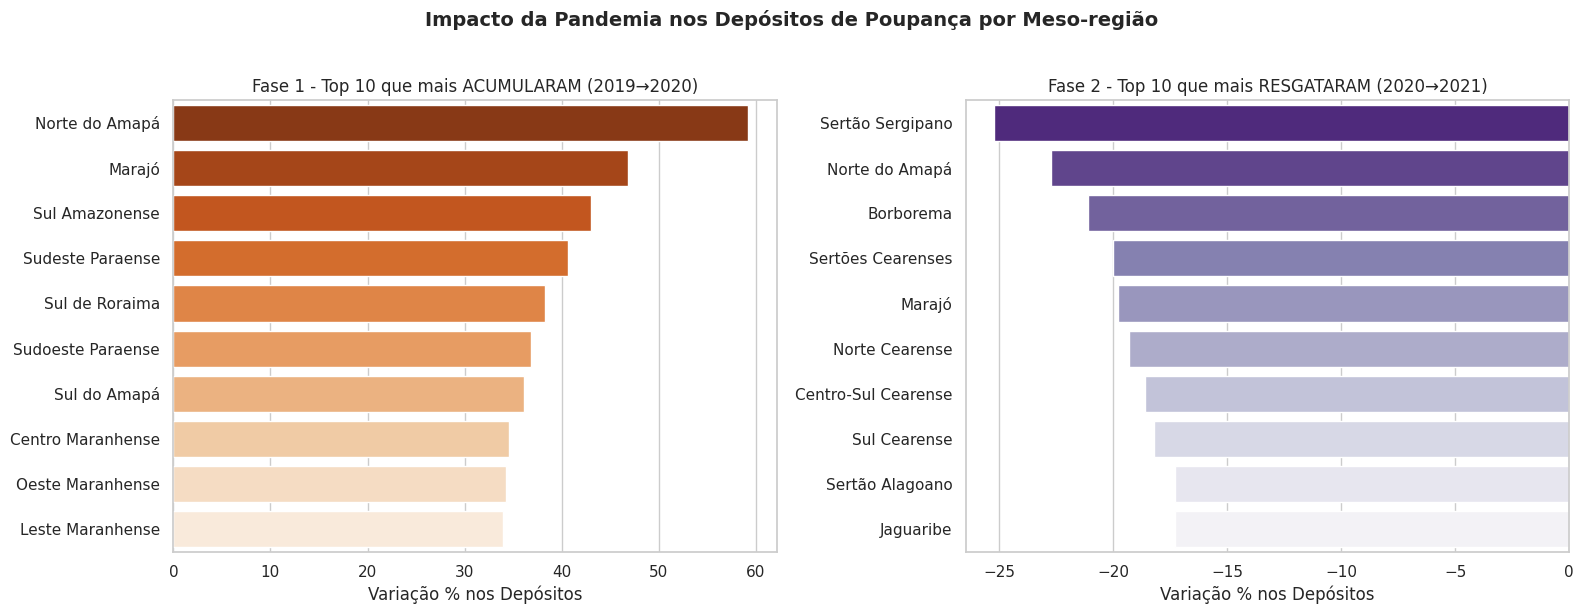

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Fase 1: Choque (2019→2020) ---
sns.barplot(
    data=top_choque,
    x='Impacto_2020_%',
    y='Meso-região',
    hue='Meso-região',
    palette='Oranges_r',
    legend=False,
    ax=ax1
)
ax1.set_title('Fase 1 - Top 10 que mais ACUMULARAM (2019→2020)',
              fontsize=12)
ax1.set_xlabel('Variação % nos Depósitos')
ax1.set_ylabel('')

# --- Fase 2: Recuperação (2020→2021) ---
sns.barplot(
    data= top_queda,
    x='Impacto_2021_%',
    y='Meso-região',
    hue='Meso-região',
    palette='Purples_r',
    legend=False,
    ax=ax2
)
ax2.set_title('Fase 2 - Top 10 que mais RESGATARAM (2020→2021)',
              fontsize=12)
ax2.set_xlabel('Variação % nos Depósitos')
ax2.set_ylabel('')

plt.suptitle('Impacto da Pandemia nos Depósitos de Poupança por Meso-região',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

💡 Hipótese complementar — limitação da análise

---
Os dados mostram que as regiões Norte e Nordeste foram as que mais acumularam poupança durante o choque pandêmico de 2020. Uma hipótese complementar, não confirmada pelos dados disponíveis, é que o elevado índice de mortalidade
nessas regiões — onde o Brasil liderou rankings globais de óbitos — pode ter contribuído para esse acúmulo, seja pela retração extrema do consumo, seja por
mecanismos de transferência de saldo. Para confirmar essa hipótese seria necessário cruzar esses dados com registros de mortalidade por região do período.


# 📝 Conclusões Finais

## 1. Síntese dos Achados

---
Ao olho nu, o dataset de Depósitos de Poupança no período de 2017 a 2022 não demonstra ser uma caixinha de surpresas, mas, no decorrer de uma análise aprofundada, surpreende com resultados inesperados e outros que se confirmaram.
Na Análise 1, foi evidenciado o nível predominante de concentração de depósitos de poupança em São Paulo. Embora não seja uma constatação inesperada, afinal, trata-se da maior metrópole do país e do estado com maior número de habitantes, o dado ainda assim revela um ponto relevante: a diferença entre SP e os demais estados com maiores níveis de concentração é considerável, chegando a equivaler à soma dos três estados seguintes no ranking.


Na Análise 2, o aprofundamento buscou identificar quais meso-regiões despontavam em crescimento e se pertenciam ao estado de maior concentração. Foi nesse momento que surgiu o primeiro paradoxo da análise: os resultados evidenciaram que as meso-regiões do Norte e do Nordeste foram as que mais cresceram percentualmente. E, ainda assim, os estados dessas mesmas regiões ocuparam as últimas posições no ranking de concentração absoluta da Análise 1.


Na Análise 3, o foco recaiu sobre duas regiões historicamente opostas em desenvolvimento econômico e social. Não houve grande surpresa ao constatar que a desigualdade entre ambas não é algo criado ou inventado: infelizmente, a desigualdade regional existe, é profunda e está estruturalmente enraizada no sistema financeiro brasileiro. O único ponto de similaridade entre Norte e Sul foi o crescimento considerável dos depósitos de poupança durante a pandemia de COVID-19.


Falando nesse marco que foi um grande divisor de águas na vida de todos, a quarta e última análise investigou os impactos sofridos por cada região durante e após a pandemia. Os resultados evidenciaram que os estados do Norte e do Nordeste foram os que mais acumularam poupança durante o período pandêmico; ao passo que, com a retomada econômica, foram os estados do Sul e do Sudeste que lideraram o resgate desses recursos. Esse movimento evidencia que a pandemia não impactou o Brasil de forma uniforme: pelo contrário, escancarou comportamentos financeiros já existentes entre regiões desenvolvidas e regiões vulneráveis.



## 2. Limitações da Análise

---
Esta análise, embora revele padrões relevantes sobre os depósitos de poupança no Brasil, possui limitações importantes que devem ser consideradas na interpretação dos resultados.

Primeiramente, o dataset não discrimina se os depósitos são de pessoas físicas ou jurídicas, o que impede afirmar que um alto volume de depósitos represente, necessariamente, concentração de riqueza individual. Complementarmente, volume de depósitos em poupança não equivale diretamente a riqueza, pessoas de alta renda tendem a alocar seus recursos em ativos mais rentáveis, como fundos de investimento, ações e imóveis, o que pode subestimar a real concentração de riqueza nas regiões mais desenvolvidas.

Outro ponto relevante é a ausência de dados sobre custo de vida e renda média por estado. Sem essas informações, não é possível confirmar se o baixo nível de depósitos nas regiões menos desenvolvidas é reflexo de uma escolha financeira ou, como é mais provável, da realidade econômica da população, o que contribuiria para explicar parte da disparidade regional observada.

No que diz respeito ao período pandêmico, duas limitações se destacam: não há dados suficientes para confirmar se a mortalidade elevada nas regiões Norte e Nordeste influenciou o acúmulo de poupança observado em 2020; tampouco é possível afirmar com certeza se a queda acentuada nos depósitos das regiões Sul e Sudeste no período pós-pandemia decorreu da retomada econômica mais acelerada dessas regiões, embora essa hipótese seja plausível.

Por fim, é fundamental destacar uma limitação estrutural do dataset: os dados registram apenas os valores dos depósitos, sem informar os motivos das variações. Toda interpretação de causa apresentada nesta análise deve ser compreendida como hipótese investigativa , não como fato comprovado.



## 3. Próximos Passos

---
Esta análise abre caminho para investigações mais aprofundadas, que poderiam ser realizadas com a incorporação de dados adicionais.

O primeiro passo natural seria ampliar o período analisado para além de 2022, incluindo anos mais recentes do pós-pandemia. Isso permitiria confirmar se a queda nos depósitos observada em 2021 e 2022 representa um movimento de reestruturação econômica temporária, ou se reflete uma ruptura mais profunda no comportamento financeiro da população, possivelmente impulsionada pelo crescimento de produtos de investimento mais rentáveis e acessíveis, como os títulos do Tesouro Direto, fundos de renda fixa e plataformas digitais de investimento.

O segundo passo seria obter uma versão do dataset que discrimine os depósitos entre pessoas físicas e jurídicas. Essa distinção permitiria separar o que representa poupança individual (e potencialmente riqueza pessoal), daquilo que reflete movimentações corporativas, tornando a análise de concentração regional muito mais precisa e significativa.

Por fim, cruzar os dados de resgates pós-pandemia com informações sobre os setores que absorveram esses recursos  consumo, investimentos, pagamento de dívidas; permitiria compreender quais foram as reais prioridades financeiras da população após o período de crise. Essa investigação transformaria a análise descritiva em uma análise comportamental, revelando não apenas o que aconteceu com a poupança, mas o que as pessoas fizeram com ela.

